In [1]:
# Figure 9

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans'],'size':15})
plt.rc('mathtext',**{'default':'regular'})
plt.rc('axes',linewidth=2)
%matplotlib inline
%config InlineBackend.figure_format='retina'


In [2]:
# GFDL data

arch = 'GFDL/'
run1 = 'REF/'
run_BS = 'BS/'
run_BSV = 'BSV/'

f_vmo='1990-2009.ocean_annual_rho2.vmo.nc'

ds_ref1=xr.open_dataset(arch + run1 + f_vmo).mean(dim='time')
ds_BS=xr.open_dataset(arch + run_BS + f_vmo).mean(dim='time')
ds_BSV=xr.open_dataset(arch + run_BSV + f_vmo).mean(dim='time')


In [3]:

field = np.sum(ds_ref1.vmo,axis=2)
grpsi_ref1 = (np.cumsum(field,axis=0) - np.sum(field,axis=0))/1e9 

field = np.sum(ds_BS.vmo,axis=2)
grpsi_BS = (np.cumsum(field,axis=0) - np.sum(field,axis=0))/1e9 

field = np.sum(ds_BSV.vmo,axis=2)
grpsi_BSV = (np.cumsum(field,axis=0) - np.sum(field,axis=0))/1e9 


In [4]:
# CESM data

arch = 'CESM/'
run2 = 'REF/'
run_MBK = 'MBK/'
run_LBK = 'LBK/'

# Years 1990-2009 correspond to years 0033-0052 in CESM runs
f_vmo='0033-0052.ocean_annual_rho2.vmo.nc'

ds_ref2=xr.open_dataset(arch + run2 + f_vmo).mean(dim='time')
ds_MBK=xr.open_dataset(arch + run_MBK + f_vmo).mean(dim='time')
ds_LBK=xr.open_dataset(arch + run_LBK + f_vmo).mean(dim='time')


In [5]:

field = np.sum(ds_ref2.vmo,axis=2)
grpsi_ref2 = (np.cumsum(field,axis=0) - np.sum(field,axis=0))/1e9 

field = np.sum(ds_MBK.vmo,axis=2)
grpsi_MBK = (np.cumsum(field,axis=0) - np.sum(field,axis=0))/1e9 

field = np.sum(ds_LBK.vmo,axis=2)
grpsi_LBK = (np.cumsum(field,axis=0) - np.sum(field,axis=0))/1e9 


/glade/derecho/scratch/chengz/tmp/ipykernel_78471/3822057743.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


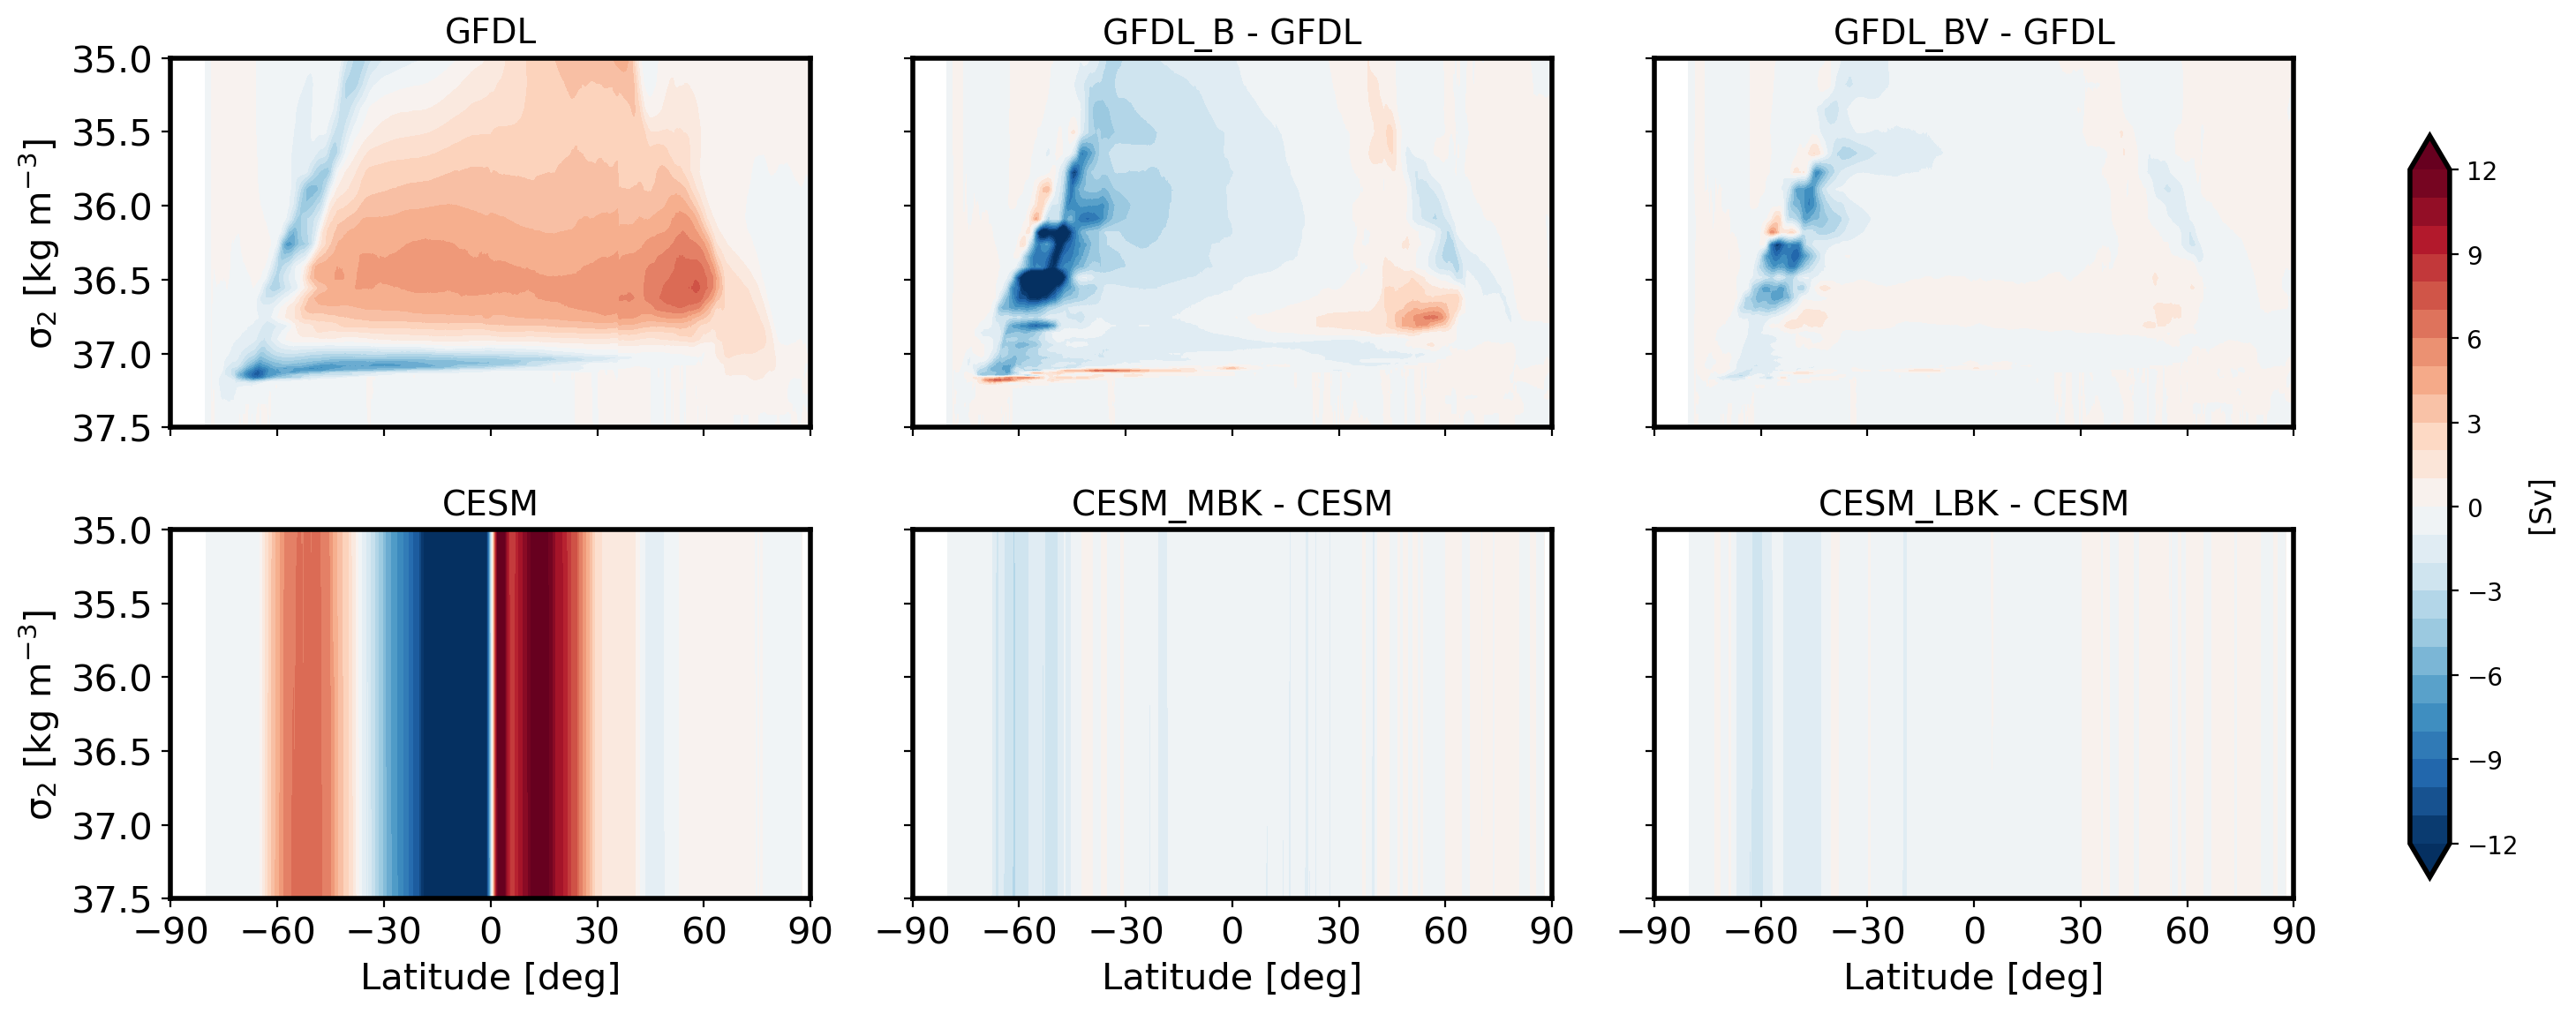

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True)

contours = np.arange(-30, 30+2, 2)
acontours = np.arange(-12, 12+1, 1)

datasets = [
    (grpsi_ref1, contours, "GFDL"),
    (grpsi_BS - grpsi_ref1, acontours, "GFDL_B - GFDL"),
    (grpsi_BSV - grpsi_ref1, acontours, "GFDL_BV - GFDL"),
    (grpsi_ref2, contours, "CESM"),
    (grpsi_MBK - grpsi_ref2, acontours, "CESM_MBK - CESM"),
    (grpsi_LBK - grpsi_ref2, acontours, "CESM_LBK - CESM"),
]

im = None

for i, ax in enumerate(axes.flat):
    field, levels, title = datasets[i]
    if i < 3:
        xcoordmesh, ycoordmesh = np.meshgrid(ds_ref1.yq, ds_ref1.rho2_l - 1000.)
    else:
        xcoordmesh, ycoordmesh = np.meshgrid(ds_ref2.yq, ds_ref2.zl)

    im = ax.contourf(
        xcoordmesh, ycoordmesh, field, 
        levels=levels, cmap="RdBu_r", extend="both"
    )

    # Panel row/col
    row, col = divmod(i, 3)
    
    # Titles
    ax.set_title(title, fontsize=14)
    
    # Axis formatting
    ax.set_xlim(-80, 90)
    ax.set_ylim([37.5, 35])
    ax.set_xticks(np.arange(-90, 100, 30))
    ax.set_yticks(np.arange(35, 37.8, 0.5))
    # ax.tick_params(labelsize=10)

    # Labels
    if col == 0:
        ax.set_ylabel(r"$\sigma_2$ [kg m$^{-3}$]")

    if row == 1:
        ax.set_xlabel("Latitude [deg]")


# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("[$Sv$]", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.9, 1])
#fig.savefig("Figure_CPT_review/GCM_MOC.pdf", dpi=800)

